# Генератор пользовательских данных для подсчета клеток крови

## HT_5: Детектирование клеток крови с YOLO

**Задача:**
1. Преобразовать генератор данных — таргет в виде `(x_center, y_center, width, height)` bounding box
2. Натренировать YOLO (Ultralytics) для детектирования клеток
3. Решить задачу подсчёта клеток с относительной погрешностью < 10%



In [ ]:
# Настройка окружения
import os
import cv2
import numpy as np
import random
import matplotlib.pyplot as plt
from typing import Tuple, List
from pathlib import Path
import yaml
from tqdm import tqdm
from torch.utils.data import Dataset

from ultralytics import YOLO

plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['axes.labelsize'] = 10

In [2]:
# Фиксация сидов для воспроизводимости
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

In [3]:
def load_bccd_patches_to_ram(bccd_img_dir: str, bccd_mask_dir: str, patch_size=64):
    """Нарезка BCCD-датасета на патчи фона и клеток."""
    bg_patches, cell_patches = [], []

    if not os.path.exists(bccd_img_dir) or not os.path.exists(bccd_mask_dir):
        print("[WARN] Папки не найдены. Будет использована только синтетика.")
        return bg_patches, cell_patches

    print("Нарезка датасета...")
    mask_files = os.listdir(bccd_mask_dir)
    mask_dict = {os.path.splitext(f)[0]: f for f in mask_files}

    for img_name in os.listdir(bccd_img_dir):
        if not img_name.lower().endswith(('.jpg', '.jpeg', '.png')):
            continue
        img = cv2.imread(os.path.join(bccd_img_dir, img_name))
        if img is None:
            continue

        base_name = os.path.splitext(img_name)[0]
        if base_name not in mask_dict:
            continue

        mask = cv2.imread(os.path.join(bccd_mask_dir, mask_dict[base_name]), cv2.IMREAD_GRAYSCALE)
        if mask is None:
            continue

        _, mask_bin = cv2.threshold(mask, 10, 255, cv2.THRESH_BINARY)
        h, w = img.shape[:2]
        step = patch_size // 2

        for y in range(0, h - patch_size + 1, step):
            for x in range(0, w - patch_size + 1, step):
                p_mask = mask_bin[y:y+patch_size, x:x+patch_size]
                p_img = img[y:y+patch_size, x:x+patch_size]

                cell_pixels = np.sum(p_mask > 0)
                total_pixels = patch_size * patch_size

                if cell_pixels > total_pixels * 0.5:
                    cell_patches.append(p_img.copy())
                elif cell_pixels == 0:
                    bg_patches.append(p_img.copy())

    print(f"Загружено: {len(bg_patches)} фонов, {len(cell_patches)} клеток.")
    return bg_patches, cell_patches

In [ ]:
class BloodCellDataset(Dataset):
    """
    Генератор изображений клеток крови для YOLO-детекции.

    Использует mask-based compositing (пиксель-в-пиксель):
    - Клетки рисуются на отдельном холсте (cells_img + cells_mask)
    - Затем накладываются на фон: result[mask > 0] = src[mask > 0]
    - Проверка перекрытия (coverage check) перед размещением
    - Тайловый фон из патчей BCCD или однотонный

    Возвращает: (image_bgr, bboxes, actual_count)
      - image_bgr: numpy.ndarray (H, W, 3) BGR
      - bboxes: list of (x_center, y_center, width, height) — нормализованные [0, 1]
      - actual_count: количество реально размещённых клеток
    """

    def __init__(
        self,
        img_size: Tuple[int, int] = (640, 640),
        dataset_size: int = 200,
        bg_patches: List[np.ndarray] = None,
        cell_patches: List[np.ndarray] = None,
        min_cells: int = 5,
        max_cells: int = 15,
        min_cell_radius: int = 12,
        max_cell_radius: int = 30,
        min_cell_coverage: float = 0.3,
        seed: int = 42
    ):
        super().__init__()
        random.seed(seed)
        np.random.seed(seed)

        self.img_size = img_size
        self.dataset_size = dataset_size
        self.bg_patches = bg_patches if bg_patches else []
        self.cell_patches = cell_patches if cell_patches else []
        self.min_cells = min_cells
        self.max_cells = max_cells
        self.min_cell_radius = min_cell_radius
        self.max_cell_radius = max_cell_radius
        self.min_cell_coverage = min_cell_coverage

    def __len__(self) -> int:
        return self.dataset_size

    def __getitem__(self, idx: int):
        h, w = self.img_size

        # Генерация фона
        clean_img = self._select_background(h, w)

        # Размещение клеток на отдельном холсте
        cells_count = random.randint(self.min_cells, self.max_cells)

        cells_img = np.zeros((h, w, 3), dtype=np.uint8)
        cells_mask = np.zeros((h, w), dtype=np.uint8)
        bboxes = []       # YOLO normalized: (x_center, y_center, w, h)
        actual_count = 0

        for _ in range(cells_count):
            placed = False
            for _attempt in range(2000):
                temp_img = np.zeros((h, w, 3), dtype=np.uint8)
                temp_mask = np.zeros((h, w), dtype=np.uint8)

                # Случайная позиция центра
                cx = random.randint(self.max_cell_radius + 5, w - self.max_cell_radius - 5)
                cy = random.randint(self.max_cell_radius + 5, h - self.max_cell_radius - 5)

                if len(self.cell_patches) > 0 and random.random() < 0.5:
                    # Реальный патч клетки
                    patch = random.choice(self.cell_patches)
                    new_size = random.randint(self.min_cell_radius * 2,
                                              self.max_cell_radius * 2)
                    patch = cv2.resize(patch, (new_size, new_size))
                    ph, pw = patch.shape[:2]

                    x1 = max(0, cx - pw // 2)
                    y1 = max(0, cy - ph // 2)
                    x2 = min(w, x1 + pw)
                    y2 = min(h, y1 + ph)

                    patch_gray = cv2.cvtColor(patch, cv2.COLOR_BGR2GRAY)
                    _, patch_mask = cv2.threshold(patch_gray, 5, 255, cv2.THRESH_BINARY)

                    temp_mask[y1:y2, x1:x2] = patch_mask[:y2-y1, :x2-x1]
                    temp_img[y1:y2, x1:x2] = patch[:y2-y1, :x2-x1]

                    # Bounding box (нормализованный)
                    bbox_w = (x2 - x1) / w
                    bbox_h = (y2 - y1) / h
                    bbox_cx = (x1 + x2) / 2 / w
                    bbox_cy = (y1 + y2) / 2 / h
                else:
                    # Синтетическая клетка (круг)
                    rad = random.randint(self.min_cell_radius, self.max_cell_radius)
                    color = self._get_cell_color()

                    cv2.circle(temp_mask, (cx, cy), rad, 255, -1)
                    cv2.circle(temp_img, (cx, cy), rad, color, -1)
                    # Ободок клетки (мембрана)
                    stroke = (min(255, color[0] + 60),
                              min(255, color[1] + 60),
                              min(255, color[2] + 60))
                    cv2.circle(temp_img, (cx, cy), rad, stroke, 2)

                    # Bounding box (нормализованный)
                    bbox_w = (2 * rad) / w
                    bbox_h = (2 * rad) / h
                    bbox_cx = cx / w
                    bbox_cy = cy / h

                # Проверка: не перекрывается ли с уже размещёнными
                overlap_mask = cv2.bitwise_and(temp_mask, cells_mask)
                new_only = cv2.bitwise_and(temp_mask, cv2.bitwise_not(cells_mask))

                total_new = np.count_nonzero(temp_mask)
                if total_new == 0:
                    continue

                coverage = np.count_nonzero(new_only) / total_new

                if coverage >= self.min_cell_coverage:
                    # Размещаем клетку
                    cells_img = self._add_image_with_mask(cells_img, temp_img, new_only)
                    cells_mask = cv2.bitwise_or(cells_mask, temp_mask)
                    bboxes.append((bbox_cx, bbox_cy, bbox_w, bbox_h))
                    actual_count += 1
                    placed = True
                    break

        # Наложение клеток на фон
        clean_img = self._add_image_with_mask(clean_img, cells_img, cells_mask)

        return clean_img, bboxes, actual_count

    def _select_background(self, h: int, w: int) -> np.ndarray:
        """Генерация фона: тилинг патчей или однотонный."""
        if len(self.bg_patches) > 0 and random.random() > 0.3:
            bg = np.zeros((h, w, 3), dtype=np.uint8)
            tile_size = 128
            for iy in range(0, h, tile_size):
                for ix in range(0, w, tile_size):
                    patch = random.choice(self.bg_patches)
                    patch = cv2.resize(patch, (tile_size, tile_size))
                    h_end = min(iy + tile_size, h)
                    w_end = min(ix + tile_size, w)
                    bg[iy:h_end, ix:w_end] = patch[:h_end-iy, :w_end-ix]
            bg = cv2.GaussianBlur(bg, (3, 3), 0)
        else:
            color = [random.randint(180, 240),
                     random.randint(180, 240),
                     random.randint(180, 240)]
            bg = np.full((h, w, 3), color, dtype=np.uint8)
        return bg

    def _get_cell_color(self) -> Tuple[int, int, int]:
        """Случайный цвет клетки (BGR)."""
        return (
            random.randint(100, 220),   # B
            random.randint(80, 200),     # G
            random.randint(80, 200)      # R
        )

    @staticmethod
    def _add_image_with_mask(dst: np.ndarray, src: np.ndarray, mask: np.ndarray) -> np.ndarray:
        """
        Надёжное наложение src на dst по маске mask (пиксель-в-пиксель).
        """
        result = dst.copy()
        result[mask > 0] = src[mask > 0]
        return result

In [ ]:
# Загрузка патчей BCCD
bccd_img_dir = "bccd/train/images"
bccd_mask_dir = "bccd/train/masks"
bg_patches_list = []
cell_patches_list = []

if os.path.exists(bccd_img_dir) and os.path.exists(bccd_mask_dir):
    bg_patches_list, cell_patches_list = load_bccd_patches_to_ram(
        bccd_img_dir=bccd_img_dir,
        bccd_mask_dir=bccd_mask_dir,
        patch_size=64
    )
else:
    print("[INFO] BCCD не найден. Используем синтетику.")

Нарезка датасета...
Загружено: 794246 фонов, 621732 клеток.
Фонов: 794246, Клеток: 621732


In [ ]:
# Параметры генерации
IMG_SIZE = (640, 640)          # Стандартный размер YOLO
TRAIN_SIZE = 2000 # 3000
VAL_SIZE   = 400 # 500
TEST_SIZE  = 100
MIN_CELLS  = 5                # Минимум клеток 
MAX_CELLS  = 15
MIN_CELL_RADIUS = 12           # Мин. радиус (bbox ~24px)
MAX_CELL_RADIUS = 30           # Макс. радиус (bbox ~60px)

YOLO_DATASET_DIR = "yolo_cell_dataset"

print(f"Генерация {TRAIN_SIZE} train + {VAL_SIZE} val изображений {IMG_SIZE}...")
print(f"Диапазон клеток: {MIN_CELLS}–{MAX_CELLS}, радиус: {MIN_CELL_RADIUS}–{MAX_CELL_RADIUS} px")

Генерация 2000 train + 400 val изображений (640, 640)...
Диапазон клеток: 5–15, радиус: 12–30 px


In [7]:
import shutil

# Очистка
if os.path.exists(YOLO_DATASET_DIR):
    shutil.rmtree(YOLO_DATASET_DIR)

for split in ['train', 'val']:
    os.makedirs(f"{YOLO_DATASET_DIR}/images/{split}", exist_ok=True)
    os.makedirs(f"{YOLO_DATASET_DIR}/labels/{split}", exist_ok=True)

CLASS_ID = 0  # единственный класс: blood_cell


def generate_yolo_dataset(split: str, num_images: int, seed: int):
    """Генерация изображений и YOLO-аннотаций."""
    dataset = BloodCellDataset(
        img_size=IMG_SIZE,
        dataset_size=num_images,
        bg_patches=bg_patches_list,
        cell_patches=cell_patches_list,
        min_cells=MIN_CELLS,
        max_cells=MAX_CELLS,
        min_cell_radius=MIN_CELL_RADIUS,
        max_cell_radius=MAX_CELL_RADIUS,
        min_cell_coverage=0.3,
        seed=seed
    )

    total_cells = 0
    empty = 0

    for i in tqdm(range(len(dataset)), desc=f"Генерация {split}"):
        clean_img, bboxes, num_cells = dataset[i]

        img_fname = f"{split}_{i:05d}.jpg"
        lbl_fname = f"{split}_{i:05d}.txt"

        cv2.imwrite(f"{YOLO_DATASET_DIR}/images/{split}/{img_fname}", clean_img)

        with open(f"{YOLO_DATASET_DIR}/labels/{split}/{lbl_fname}", 'w') as f:
            for (xc, yc, bw, bh) in bboxes:
                f.write(f"{CLASS_ID} {xc:.6f} {yc:.6f} {bw:.6f} {bh:.6f}\n")

        total_cells += num_cells
        if num_cells == 0:
            empty += 1

    print(f"  {split}: {num_images} изображений, "
          f"{total_cells} клеток (ср. {total_cells/num_images:.1f}/img), "
          f"{empty} пустых")


generate_yolo_dataset('train', TRAIN_SIZE, seed=SEED)
generate_yolo_dataset('val', VAL_SIZE, seed=SEED + 1)

Генерация train: 100%|██████████| 2000/2000 [00:55<00:00, 36.14it/s]


  train: 2000 изображений, 20248 клеток (ср. 10.1/img), 0 пустых


Генерация val: 100%|██████████| 400/400 [00:10<00:00, 38.12it/s]

  val: 400 изображений, 3929 клеток (ср. 9.8/img), 0 пустых


In [8]:
# Создание data.yaml
data_yaml = {
    'path': os.path.abspath(YOLO_DATASET_DIR),
    'train': 'images/train',
    'val': 'images/val',
    'names': {0: 'blood_cell'},
    'nc': 1
}

yaml_path = f"{YOLO_DATASET_DIR}/data.yaml"
with open(yaml_path, 'w') as f:
    yaml.dump(data_yaml, f, default_flow_style=False)

print(f"data.yaml: {yaml_path}")
print(yaml.dump(data_yaml, default_flow_style=False))

data.yaml: yolo_cell_dataset/data.yaml
names:
  0: blood_cell
nc: 1
path: "c:\\Users\\Daniil\\Desktop\\Recent Study\\2 \u0441\u0435\u043C\u0435\u0441\u0442\
  \u0440\\\u0414\u0432\u0443\u043C\u0435\u0440\u043D\u0430\u044F \u0433\u0440\u0430\
  \u0444\u0438\u043A\u0430 \u0438 \u043E\u0431\u0440\u0430\u0431\u043E\u0442\u043A\
  \u0430 \u0432\u0438\u0434\u0435\u043E\\Practice_5\\yolo_cell_dataset"
train: images/train
val: images/val



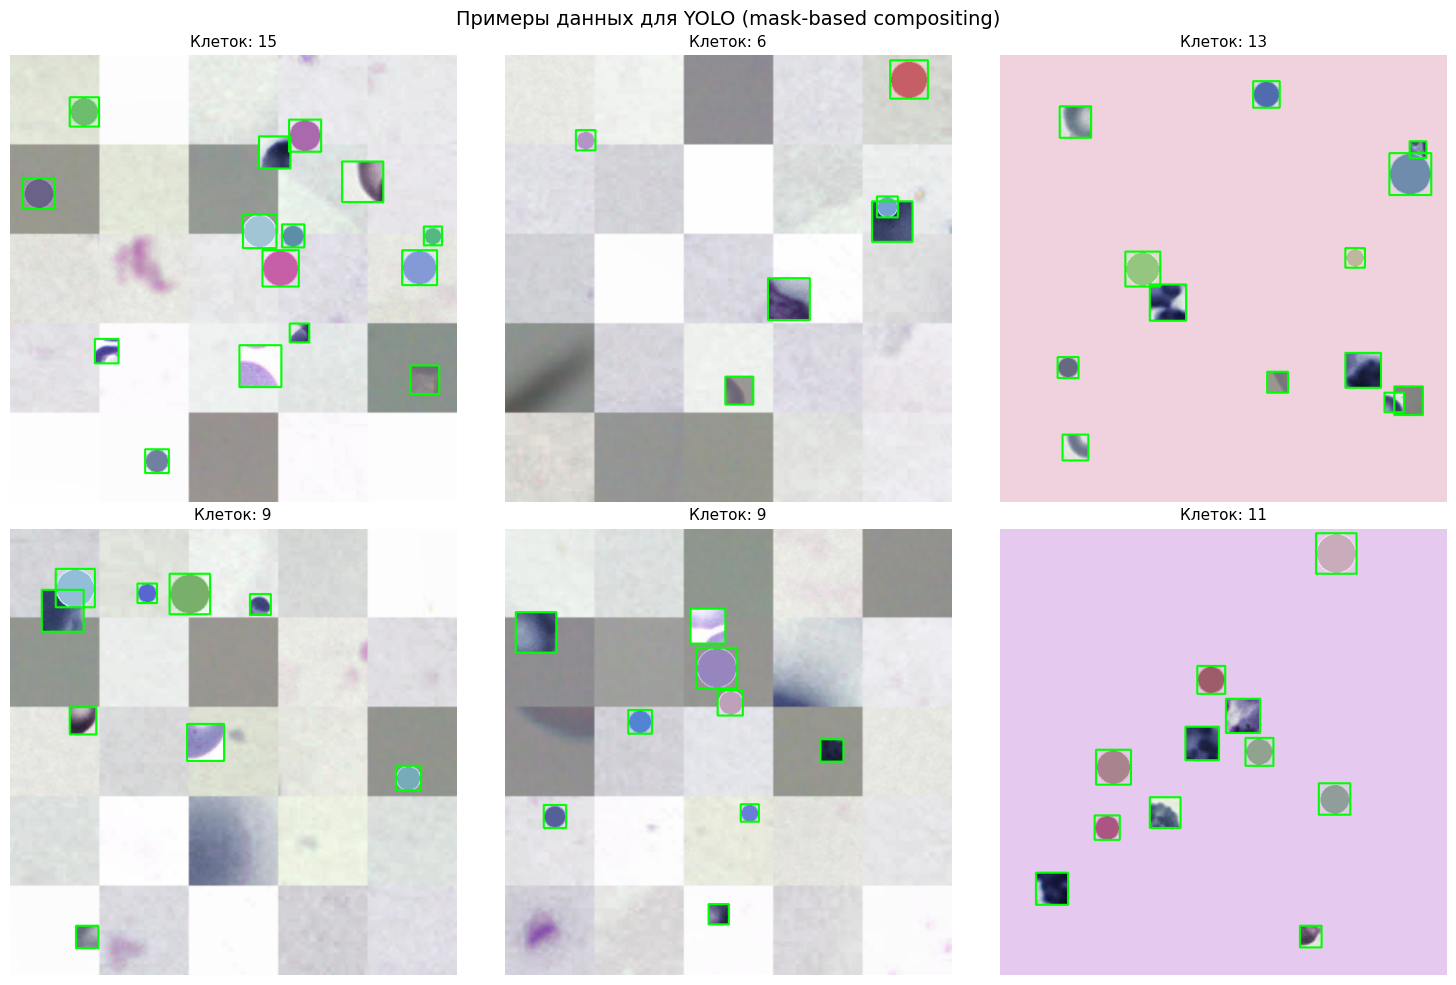

In [9]:
# Визуализация примеров с bounding boxes
def draw_bboxes(img_bgr, bboxes, color=(0, 255, 0), thickness=2):
    """Отрисовка YOLO bboxes на BGR-изображении."""
    img = img_bgr.copy()
    h, w = img.shape[:2]
    for (xc, yc, bw, bh) in bboxes:
        x1 = int((xc - bw / 2) * w)
        y1 = int((yc - bh / 2) * h)
        x2 = int((xc + bw / 2) * w)
        y2 = int((yc + bh / 2) * h)
        cv2.rectangle(img, (x1, y1), (x2, y2), color, thickness)
    return img


random.seed(SEED)
dataset_viz = BloodCellDataset(
    img_size=IMG_SIZE, dataset_size=6,
    bg_patches=bg_patches_list, cell_patches=cell_patches_list,
    min_cells=MIN_CELLS, max_cells=MAX_CELLS,
    min_cell_radius=MIN_CELL_RADIUS, max_cell_radius=MAX_CELL_RADIUS,
    seed=SEED
)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle("Примеры данных для YOLO (mask-based compositing)", fontsize=14)

for i in range(6):
    clean_img, bboxes, num_cells = dataset_viz[i]
    drawn = draw_bboxes(clean_img, bboxes)
    drawn_rgb = cv2.cvtColor(drawn, cv2.COLOR_BGR2RGB)

    row, col = i // 3, i % 3
    axes[row, col].imshow(drawn_rgb)
    axes[row, col].set_title(f"Клеток: {num_cells}", fontsize=11)
    axes[row, col].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
# Выбор модели YOLOv8n (nano)
model = YOLO('yolov8n.pt') 

print(f"Модель: YOLOv8n (nano)")
print(f"Классов в модели: {model.nc}")

Модель: YOLOv8n (nano)
Классов в модели: 80


In [11]:
# Тренировка YOLO
results = model.train(
    data=yaml_path,
    epochs=100,
    imgsz=640,
    batch=16,
    lr0=0.01,        # стандартная начальная LR для YOLO
    lrf=0.01,        # финальная LR (cosine decay)
    patience=20,     # ранняя остановка
    name='yolo_cell_detect',
    exist_ok=True,
    verbose=True,
    seed=SEED
)

print("\nТренировка завершена!")
print(f"Лучший mAP50:    {results.results_dict.get('metrics/mAP50(B)', 'N/A')}")
print(f"Лучший mAP50-95: {results.results_dict.get('metrics/mAP50-95(B)', 'N/A')}")

Ultralytics 8.4.56  Python-3.14.3 torch-2.11.0+cu128 CUDA:0 (NVIDIA GeForce RTX 5070 Laptop GPU, 8151MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=yolo_cell_dataset/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolo_cell_detect, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, 

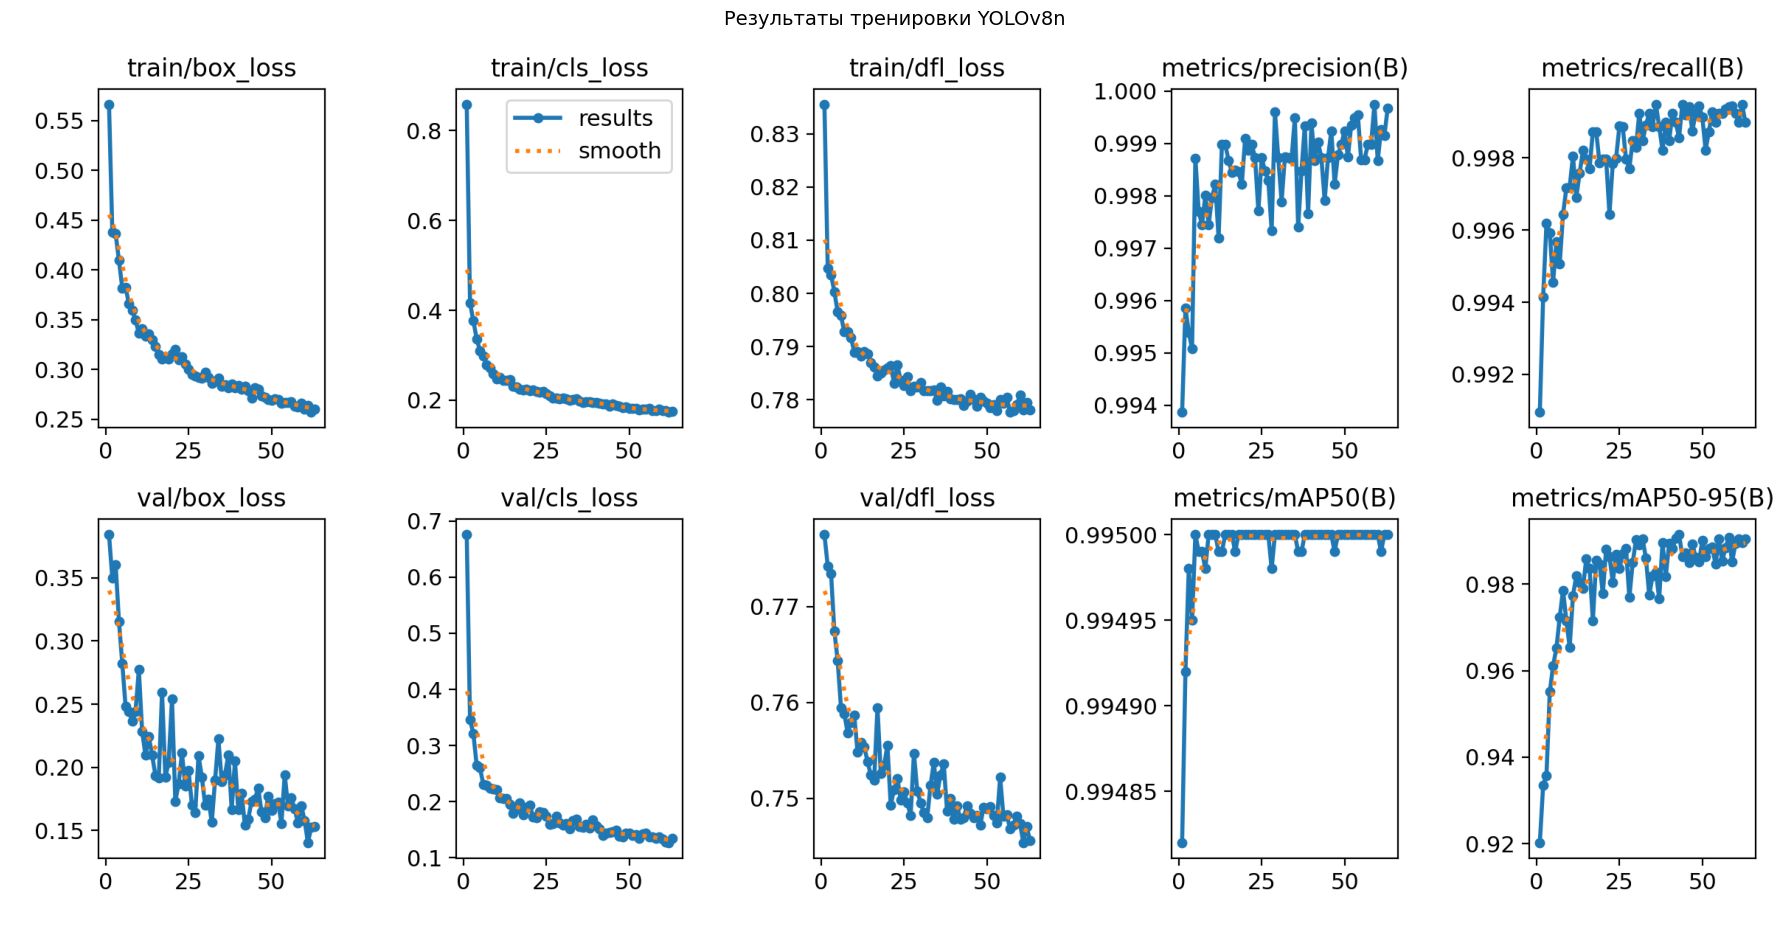

In [12]:
# Графики тренировки
from PIL import Image

results_dir = 'runs/detect/yolo_cell_detect'
results_img_path = f"{results_dir}/results.png"
if os.path.exists(results_img_path):
    img = Image.open(results_img_path)
    fig, ax = plt.subplots(figsize=(18, 12))
    ax.imshow(img)
    ax.axis('off')
    ax.set_title("Результаты тренировки YOLOv8n", fontsize=14)
    plt.tight_layout()
    plt.show()
else:
    print(f"Файл {results_img_path} не найден.")

In [13]:
# Загрузка лучшей модели
best_model_path = f"{results_dir}/weights/best.pt"
best_model = YOLO(best_model_path)
print(f"Модель загружена: {best_model_path}")

Модель загружена: runs/detect/yolo_cell_detect/weights/best.pt


In [14]:
# Валидация YOLO (стандартные метрики)
val_results = best_model.val(
    data=yaml_path,
    imgsz=640,
    conf=0.25,
    iou=0.5,
    split='val',
    save=True,
    save_txt=True,
    name='yolo_cell_val',
    exist_ok=True,
    verbose=True
)

print(f"\nmAP50:     {val_results.box.map50:.4f}")
print(f"mAP50-95:  {val_results.box.map:.4f}")
print(f"Precision: {val_results.box.mp:.4f}")
print(f"Recall:     {val_results.box.mr:.4f}")

Ultralytics 8.4.56  Python-3.14.3 torch-2.11.0+cu128 CUDA:0 (NVIDIA GeForce RTX 5070 Laptop GPU, 8151MiB)
Model summary (fused): 73 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access  (ping: 0.00.0 ms, read: 354.0263.8 MB/s, size: 29.4 KB)
val: Scanning C:\Users\Daniil\Desktop\Recent Study\2 семестр\Двумерная графика и обработка видео\Practice_5\yolo_cell_dataset\labels\val.cache... 400 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 400/400 152.5Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 25/25 3.9it/s 6.4s0.2s
                   all        400       3929      0.999      0.998      0.995      0.992
Speed: 1.7ms preprocess, 2.1ms inference, 0.0ms loss, 1.3ms postprocess per image
Results saved to C:\Users\Daniil\Desktop\Recent Study\2 \    \Practice_5\runs\detect\yolo_cell_val

mAP50:     0.9950
mAP50-95:  0.9917
Precision: 0.9987
Recall:     0.9981


In [ ]:
# Тюнинг порога уверенности (confidence threshold)

gt_dir = f"{YOLO_DATASET_DIR}/labels/val"
val_img_dir = f"{YOLO_DATASET_DIR}/images/val"

# Загружаем GT
image_names = sorted([f.replace('.txt', '') for f in os.listdir(gt_dir) if f.endswith('.txt')])
gt_counts = {}
for name in image_names:
    with open(os.path.join(gt_dir, f"{name}.txt")) as f:
        gt_counts[name] = len([l for l in f.readlines() if l.strip()])

# Прогоняем модель с conf=0.01 на КАЖДОМ изображении валидации и сохраняем все детекции с confidence
print(f"Инференс модели на {len(image_names)} val изобр. (conf=0.01)...")
all_detections = {}  # name -> [(conf, x, y, w, h), ...]

for name in tqdm(image_names):
    img_path = os.path.join(val_img_dir, f"{name}.jpg")
    results = best_model(img_path, conf=0.01, verbose=False)

    dets = []
    if results and len(results) > 0 and results[0].boxes is not None:
        for box in results[0].boxes:
            conf = box.conf[0].item()
            # xywhn = нормализованные координаты (0..1)
            xywh = box.xywhn[0].tolist()
            dets.append((conf, xywh[0], xywh[1], xywh[2], xywh[3]))

    all_detections[name] = dets

# Подбираем лучший conf
print(f"\n{'='*65}")
print(f"{'Conf':>6} | {'<10%':>6} | {'MAE':>6} | {'Mean RE':>8} | {'Вердикт':>10}")
print("-" * 65)

best_conf = 0.25
best_pct = 0

for conf_thresh in np.arange(0.05, 0.60, 0.05):
    correct = 0
    total = len(image_names)
    abs_errors = []
    rel_errors_valid = []

    for name in image_names:
        gt = gt_counts[name]
        # Фильтруем по порогу confidence (conf — первый элемент кортежа)
        pred_count = sum(1 for (conf, _, _, _, _) in all_detections.get(name, [])
                         if conf >= conf_thresh)

        abs_err = abs(pred_count - gt)
        abs_errors.append(abs_err)

        if gt > 0:
            rel_err = abs_err / gt
            rel_errors_valid.append(rel_err)
            if rel_err < 0.10:
                correct += 1
        elif pred_count == 0:
            correct += 1

    pct = correct / total * 100
    mae = np.mean(abs_errors)
    mean_re = np.mean(rel_errors_valid) if rel_errors_valid else 0

    verdict = "***" if pct >= 90 else ""
    print(f"{conf_thresh:6.2f} | {pct:5.1f}% | {mae:6.2f} | {mean_re:8.4f} | {verdict:>10}")

    if pct > best_pct:
        best_pct = pct
        best_conf = conf_thresh

print("-" * 65)
print(f"ЛУЧШИЙ conf = {best_conf:.2f} → {best_pct:.1f}% изображений с погрешностью < 10%")
print(f"{'='*65}")

Инференс модели на 400 val изобр. (conf=0.01)...


100%|██████████| 400/400 [00:05<00:00, 72.36it/s]


  Conf |   <10% |    MAE |  Mean RE |    Вердикт
-----------------------------------------------------------------
  0.05 |  94.2% |   0.16 |   0.0177 |        ***
  0.10 |  95.8% |   0.11 |   0.0125 |        ***
  0.15 |  96.5% |   0.09 |   0.0104 |        ***
  0.20 |  97.5% |   0.07 |   0.0082 |        ***
  0.25 |  98.2% |   0.06 |   0.0069 |        ***
  0.30 |  98.2% |   0.06 |   0.0063 |        ***
  0.35 |  98.2% |   0.05 |   0.0059 |        ***
  0.40 |  98.5% |   0.05 |   0.0052 |        ***
  0.45 |  98.8% |   0.03 |   0.0035 |        ***
  0.50 |  98.8% |   0.03 |   0.0031 |        ***
  0.55 |  98.8% |   0.03 |   0.0031 |        ***
-----------------------------------------------------------------
ЛУЧШИЙ conf = 0.45 → 98.8% изображений с погрешностью < 10%


In [ ]:
# Детальный анализ подсчёта с лучшим conf
OPTIMAL_CONF = best_conf 

correct = 0
total = len(image_names)
gt_arr = []
pred_arr = []
error_details = []

for name in image_names:
    gt = gt_counts[name]
    pred_count = sum(1 for (conf, _, _, _, _) in all_detections.get(name, [])
                     if conf >= OPTIMAL_CONF)

    gt_arr.append(gt)
    pred_arr.append(pred_count)

    if gt > 0:
        rel_err = abs(pred_count - gt) / gt
    else:
        rel_err = 0.0 if pred_count == 0 else float('inf')

    ok = rel_err < 0.10
    if ok:
        correct += 1

    error_details.append({
        'name': name,
        'gt': gt,
        'pred': pred_count,
        'rel_err': rel_err,
        'ok': ok
    })

gt_arr = np.array(gt_arr)
pred_arr = np.array(pred_arr)

print(f"{'='*65}")
print(f"РЕЗУЛЬТАТЫ ПОДСЧЁТА КЛЕТОК (conf={OPTIMAL_CONF:.2f})")
print(f"{'='*65}")
print(f"Всего изображений: {total}")
print(f"Корректных (< 10%): {correct}/{total} ({correct/total*100:.1f}%)")
print(f"Средний GT:  {gt_arr.mean():.1f}")
print(f"Средний Pred: {pred_arr.mean():.1f}")
print(f"MAE: {np.mean(np.abs(pred_arr - gt_arr)):.2f} клеток")

valid_re = [e['rel_err'] for e in error_details if e['rel_err'] != float('inf')]
print(f"Средняя относ. ошибка: {np.mean(valid_re):.4f}")

print(f"\nСтатистика по количеству клеток (GT):")
for c in sorted(set(gt_arr)):
    mask = gt_arr == c
    n = mask.sum()
    preds_c = pred_arr[mask]
    mae_c = np.mean(np.abs(preds_c - c))
    print(f"  GT={c:2d}: {n:3d} изобр., MAE={mae_c:.2f}, ср. pred={preds_c.mean():.1f}")

if correct / total >= 0.9:
    print(f"\n✓ ЦЕЛЬ ДОСТИГНУТА: {correct/total*100:.1f}% ≥ 90%")
else:
    print(f"\n✗ Цель НЕ достигнута: {correct/total*100:.1f}% < 90%")

РЕЗУЛЬТАТЫ ПОДСЧЁТА КЛЕТОК (conf=0.45)
Всего изображений: 400
Корректных (< 10%): 395/400 (98.8%)
Средний GT:  9.8
Средний Pred: 9.8
MAE: 0.03 клеток
Средняя относ. ошибка: 0.0035

Статистика по количеству клеток (GT):
  GT= 5:  49 изобр., MAE=0.04, ср. pred=5.0
  GT= 6:  35 изобр., MAE=0.03, ср. pred=6.0
  GT= 7:  35 изобр., MAE=0.03, ср. pred=7.0
  GT= 8:  41 изобр., MAE=0.00, ср. pred=8.0
  GT= 9:  39 изобр., MAE=0.00, ср. pred=9.0
  GT=10:  27 изобр., MAE=0.00, ср. pred=10.0
  GT=11:  30 изобр., MAE=0.00, ср. pred=11.0
  GT=12:  35 изобр., MAE=0.14, ср. pred=12.1
  GT=13:  36 изобр., MAE=0.06, ср. pred=13.0
  GT=14:  33 изобр., MAE=0.03, ср. pred=14.0
  GT=15:  40 изобр., MAE=0.03, ср. pred=15.0

✓ ЦЕЛЬ ДОСТИГНУТА: 98.8% ≥ 90%


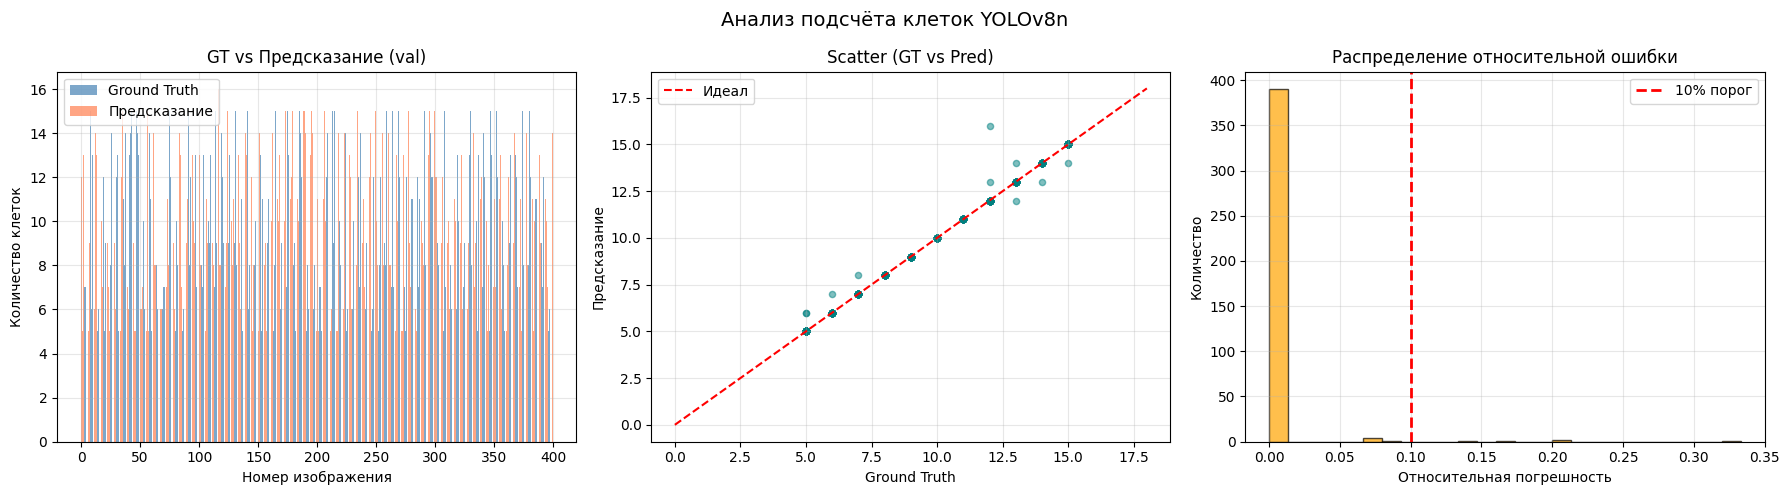

In [17]:
# Визуализация результатов
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Сравнение GT vs Pred
axes[0].bar(np.arange(len(gt_arr)) - 0.2, gt_arr, 0.4, label='Ground Truth', color='steelblue', alpha=0.7)
axes[0].bar(np.arange(len(pred_arr)) + 0.2, pred_arr, 0.4, label='Предсказание', color='coral', alpha=0.7)
axes[0].set_xlabel("Номер изображения")
axes[0].set_ylabel("Количество клеток")
axes[0].set_title("GT vs Предсказание (val)")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 2. Scatter
axes[1].scatter(gt_arr, pred_arr, alpha=0.5, s=20, c='teal')
max_val = max(gt_arr.max(), pred_arr.max()) + 2
axes[1].plot([0, max_val], [0, max_val], 'r--', label='Идеал')
axes[1].set_xlabel("Ground Truth")
axes[1].set_ylabel("Предсказание")
axes[1].set_title("Scatter (GT vs Pred)")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# 3. Распределение относительной ошибки
rel_errors = [e['rel_err'] for e in error_details if e['rel_err'] != float('inf')]
axes[2].hist(rel_errors, bins=25, color='orange', edgecolor='black', alpha=0.7)
axes[2].axvline(x=0.1, color='red', linestyle='--', linewidth=2, label='10% порог')
axes[2].set_xlabel("Относительная погрешность")
axes[2].set_ylabel("Количество")
axes[2].set_title("Распределение относительной ошибки")
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.suptitle("Анализ подсчёта клеток YOLOv8n", fontsize=14)
plt.tight_layout()
plt.show()

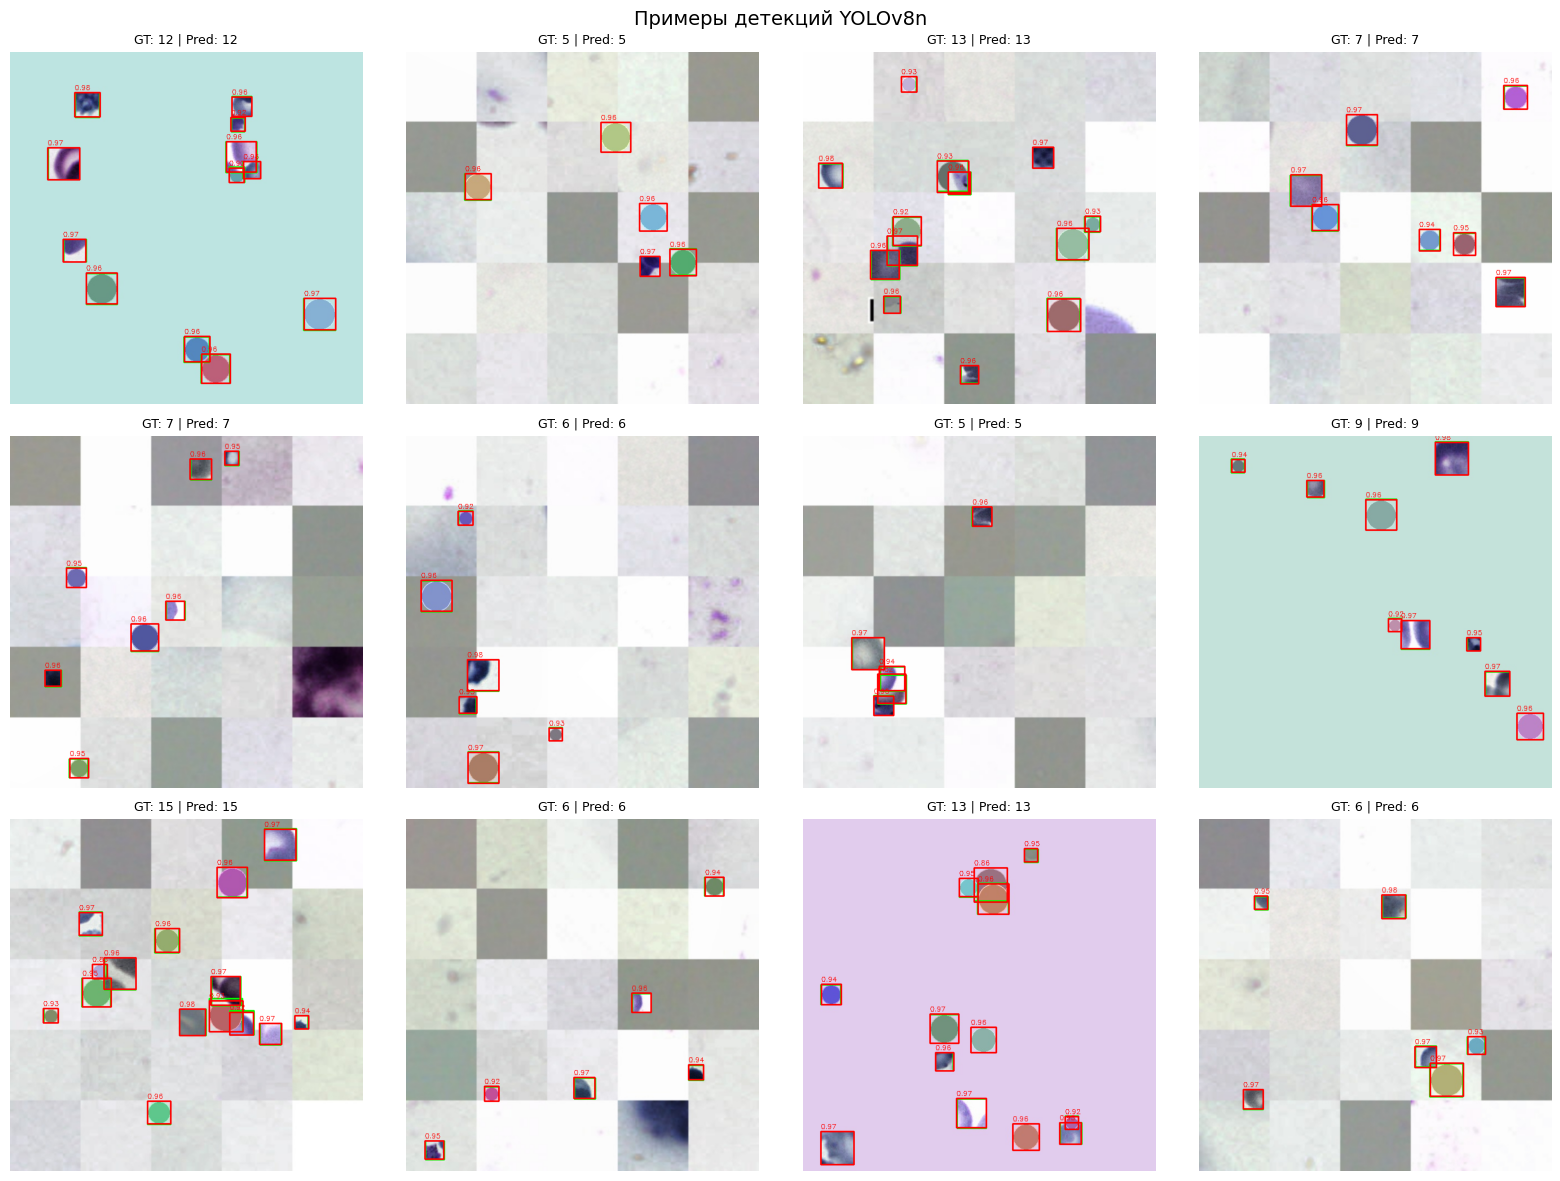

Зелёные — ground truth, красные — предсказания YOLO


In [ ]:
# Визуализация детекций на примерах
val_img_dir = f"{YOLO_DATASET_DIR}/images/val"
sample_images = sorted(os.listdir(val_img_dir))[:12]

fig, axes = plt.subplots(3, 4, figsize=(16, 12))
fig.suptitle("Примеры детекций YOLOv8n", fontsize=14)

for i, img_name in enumerate(sample_images):
    img_path = os.path.join(val_img_dir, img_name)
    img = cv2.imread(img_path)

    base_name = img_name.replace('.jpg', '')

    # GT bboxes (зелёные)
    gt_path = os.path.join(gt_dir, f"{base_name}.txt")
    gt_bboxes = []
    with open(gt_path) as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) >= 5:
                gt_bboxes.append((float(parts[1]), float(parts[2]),
                                  float(parts[3]), float(parts[4])))

    # YOLO предсказания (красные)
    pred = best_model(img_path, conf=OPTIMAL_CONF, verbose=False)

    h, w = img.shape[:2]
    for (xc, yc, bw, bh) in gt_bboxes:
        x1 = int((xc - bw / 2) * w)
        y1 = int((yc - bh / 2) * h)
        x2 = int((xc + bw / 2) * w)
        y2 = int((yc + bh / 2) * h)
        cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 2)

    if pred and pred[0].boxes is not None:
        for box in pred[0].boxes:
            bx1, by1, bx2, by2 = box.xyxy[0].int().tolist()
            conf = box.conf[0].item()
            cv2.rectangle(img, (bx1, by1), (bx2, by2), (0, 0, 255), 2)
            cv2.putText(img, f"{conf:.2f}", (bx1, by1 - 5),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.4, (0, 0, 255), 1)

    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    row, col = i // 4, i % 4
    axes[row, col].imshow(img_rgb)

    gt_count = len(gt_bboxes)
    pred_count = len(pred[0].boxes) if pred and pred[0].boxes else 0
    axes[row, col].set_title(f"GT: {gt_count} | Pred: {pred_count}", fontsize=9)
    axes[row, col].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
# Итоговый тест на 100 новых изображениях
test_dir = "yolo_cell_test"
if os.path.exists(test_dir):
    shutil.rmtree(test_dir)
os.makedirs(f"{test_dir}/images", exist_ok=True)
os.makedirs(f"{test_dir}/labels", exist_ok=True)

test_dataset = BloodCellDataset(
    img_size=IMG_SIZE, dataset_size=TEST_SIZE,
    bg_patches=bg_patches_list, cell_patches=cell_patches_list,
    min_cells=MIN_CELLS, max_cells=MAX_CELLS,
    min_cell_radius=MIN_CELL_RADIUS, max_cell_radius=MAX_CELL_RADIUS,
    seed=SEED + 999
)

test_results = []

for i in tqdm(range(len(test_dataset)), desc="Тест"):
    clean_img, bboxes, gt_count = test_dataset[i]

    img_name = f"test_{i:05d}.jpg"
    cv2.imwrite(f"{test_dir}/images/{img_name}", clean_img)

    with open(f"{test_dir}/labels/{img_name.replace('.jpg', '.txt')}", 'w') as f:
        for (xc, yc, bw, bh) in bboxes:
            f.write(f"{CLASS_ID} {xc:.6f} {yc:.6f} {bw:.6f} {bh:.6f}\n")

    # Детекция с оптимальным conf
    pred = best_model(f"{test_dir}/images/{img_name}", conf=OPTIMAL_CONF, verbose=False)
    pred_count = len(pred[0].boxes) if pred and pred[0].boxes else 0

    if gt_count > 0:
        rel_err = abs(pred_count - gt_count) / gt_count
    else:
        rel_err = 0.0 if pred_count == 0 else float('inf')

    test_results.append({
        'img': img_name,
        'gt': gt_count,
        'pred': pred_count,
        'rel_err': rel_err,
        'ok': rel_err < 0.10
    })

# Анализ
total_t = len(test_results)
correct_t = sum(1 for r in test_results if r['ok'])
gt_arr_t = np.array([r['gt'] for r in test_results])
pred_arr_t = np.array([r['pred'] for r in test_results])
valid_errors_t = [r['rel_err'] for r in test_results if r['rel_err'] != float('inf')]

print(f"\n{'='*65}")
print(f"ИТОГОВЫЙ ТЕСТ ({total_t} изображений, seed={SEED + 999})")
print(f"{'='*65}")
print(f"Корректных (< 10% погрешность): {correct_t}/{total_t} ({correct_t/total_t*100:.1f}%)")
print(f"MAE: {np.mean(np.abs(pred_arr_t - gt_arr_t)):.2f} клеток")
print(f"Средняя относ. ошибка: {np.mean(valid_errors_t):.4f}")

print(f"\nДетализация по количеству клеток:")
for c in sorted(set(gt_arr_t)):
    mask = gt_arr_t == c
    n = mask.sum()
    preds_c = pred_arr_t[mask]
    mae_c = np.mean(np.abs(preds_c - c))
    print(f"  GT={c:2d}: {n:3d} изобр., MAE={mae_c:.2f}")

if correct_t / total_t >= 0.9:
    print(f"\n✓ ЦЕЛЬ ДОСТИГНУТА: {correct_t/total_t*100:.1f}% ≥ 90%")
else:
    print(f"\n✗ Цель НЕ достигнута: {correct_t/total_t*100:.1f}% < 90%")

Тест: 100%|██████████| 100/100 [00:04<00:00, 21.35it/s]


ИТОГОВЫЙ ТЕСТ (100 изображений, seed=1041)
Корректных (< 10% погрешность): 99/100 (99.0%)
MAE: 0.03 клеток
Средняя относ. ошибка: 0.0026

Детализация по количеству клеток:
  GT= 5:   7 изобр., MAE=0.00
  GT= 6:  12 изобр., MAE=0.00
  GT= 7:   6 изобр., MAE=0.00
  GT= 8:   8 изобр., MAE=0.00
  GT= 9:  10 изобр., MAE=0.10
  GT=10:   7 изобр., MAE=0.00
  GT=11:   8 изобр., MAE=0.00
  GT=12:  12 изобр., MAE=0.00
  GT=13:  13 изобр., MAE=0.08
  GT=14:   7 изобр., MAE=0.14
  GT=15:  10 изобр., MAE=0.00

✓ ЦЕЛЬ ДОСТИГНУТА: 99.0% ≥ 90%


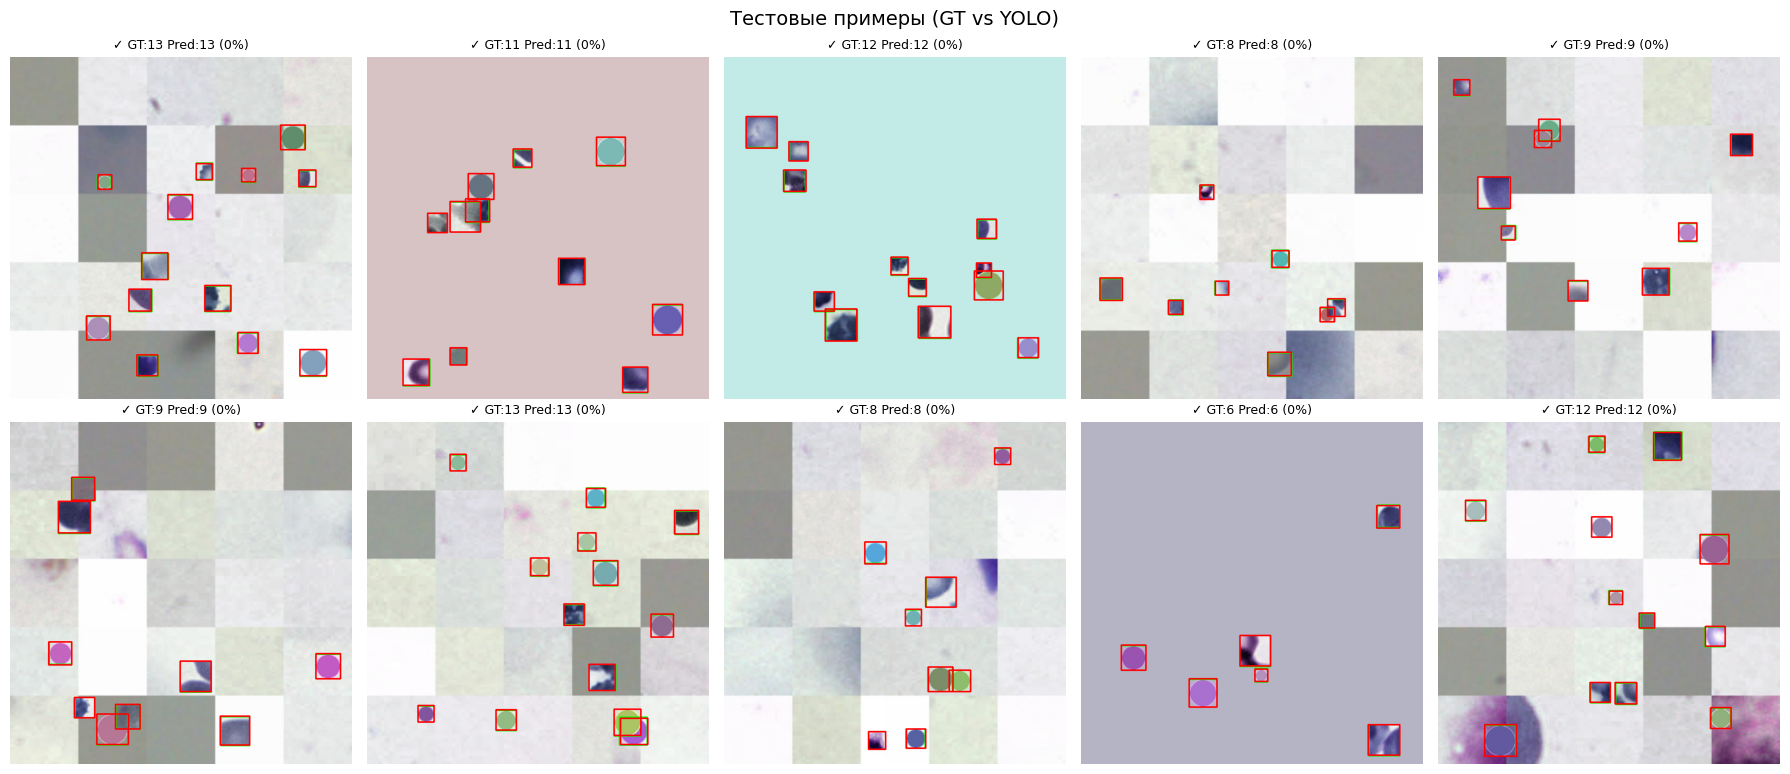

Зелёные — GT, красные — YOLO


In [ ]:
# Визуализация тестовых результатов
fig, axes = plt.subplots(2, 5, figsize=(18, 8))
fig.suptitle("Тестовые примеры (GT vs YOLO)", fontsize=14)

for i in range(10):
    r = test_results[i]
    img_path = f"{test_dir}/images/{r['img']}"
    img = cv2.imread(img_path)

    # GT bboxes (зелёные)
    base = r['img'].replace('.jpg', '')
    gt_path = f"{test_dir}/labels/{base}.txt"
    h, w = img.shape[:2]
    with open(gt_path) as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) >= 5:
                xc, yc, bw, bh = float(parts[1]), float(parts[2]), float(parts[3]), float(parts[4])
                x1 = int((xc - bw / 2) * w)
                y1 = int((yc - bh / 2) * h)
                x2 = int((xc + bw / 2) * w)
                y2 = int((yc + bh / 2) * h)
                cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 2)

    # YOLO предсказания
    pred = best_model(img_path, conf=OPTIMAL_CONF, verbose=False)
    if pred and pred[0].boxes is not None:
        for box in pred[0].boxes:
            bx1, by1, bx2, by2 = box.xyxy[0].int().tolist()
            cv2.rectangle(img, (bx1, by1), (bx2, by2), (0, 0, 255), 2)

    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    row, col = i // 5, i % 5
    axes[row, col].imshow(img_rgb)

    status = '✓' if r['ok'] else '✗'
    err_pct = f"{r['rel_err']*100:.0f}%" if r['rel_err'] != float('inf') else '∞'
    axes[row, col].set_title(f"{status} GT:{r['gt']} Pred:{r['pred']} ({err_pct})", fontsize=9)
    axes[row, col].axis('off')

plt.tight_layout()
plt.show()

In [21]:
# Сохранение модели
save_path = "yolo_cell_model.pt"
best_model.save(save_path)
print(f"Модель сохранена: {save_path}")

Модель сохранена: yolo_cell_model.pt
